D:\ANACONDA\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.6051 - loss: 0.6465 - val_accuracy: 0.7312 - val_loss: 0.5341
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.8266 - loss: 0.3926 - val_accuracy: 0.7980 - val_loss: 0.4524
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.9197 - loss: 0.2122 - val_accuracy: 0.8330 - val_loss: 0.4660
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.9643 - loss: 0.1065 - val_accuracy: 0.8244 - val_loss: 0.5747
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9905 - loss: 0.0390 - val_accuracy: 0.7830 - val_loss: 0.6591
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.7742 - loss: 0.6750
Test Accuracy: 0.7742000222206116
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step


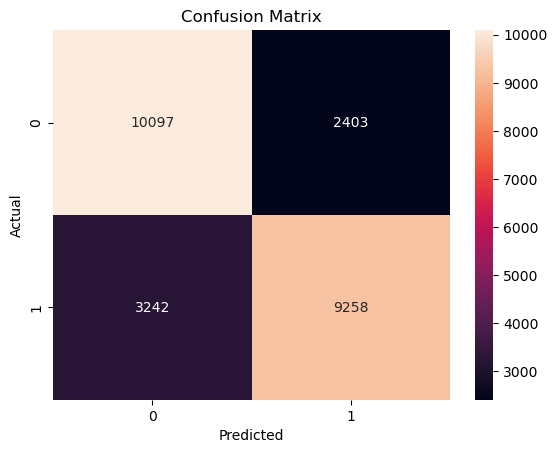


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78     12500
           1       0.79      0.74      0.77     12500

    accuracy                           0.77     25000
   macro avg       0.78      0.77      0.77     25000
weighted avg       0.78      0.77      0.77     25000



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Load Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# 🔹 Padding
max_length = 200
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

# 🔹 Model
model = Sequential()
model.add(Embedding(vocab_size, 32, input_length=max_length))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# 🔹 Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# 🔹 Predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 🔹 Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))